In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "merged_mpu_data_all.csv"
df = pd.read_csv(CSV_PATH)

expected_cols = {"timestamp_ms","ax","ay","az","label"}
missing = expected_cols - set(map(str.lower, df.columns))

df["mag"] = np.sqrt(df["ax"]**2 + df["ay"]**2 + df["az"]**2)

In [ ]:
display_cols = ["timestamp_ms","ax","ay","az","mag","label"]
display_cols = [c for c in display_cols if c in df.columns]
pd.set_option("display.float_format", lambda x: f"{x:.6f}")
display(df[display_cols].head(21))

,timestamp_ms,ax,ay,az,mag,label
0,3020059,-0.989990,-0.020508,0.000000,0.990202,left
1,3020080,-0.987549,-0.022217,-0.010010,0.987850,left
2,3020101,-0.985840,-0.008789,-0.011475,0.985946,left
3,3020122,-0.995361,-0.016846,-0.007568,0.995532,left
4,3020143,-0.987549,-0.014160,-0.002441,0.987654,left
5,3020164,-0.988770,-0.011963,-0.012207,0.988918,left
6,3020185,-0.992432,-0.004395,-0.015381,0.992561,left
7,3020206,-1.002441,-0.011719,-0.015137,1.002624,left
8,3020227,-0.988037,-0.011719,-0.011963,0.988179,left
9,3020248,-0.995605,-0.022705,-0.007813,0.995895,left


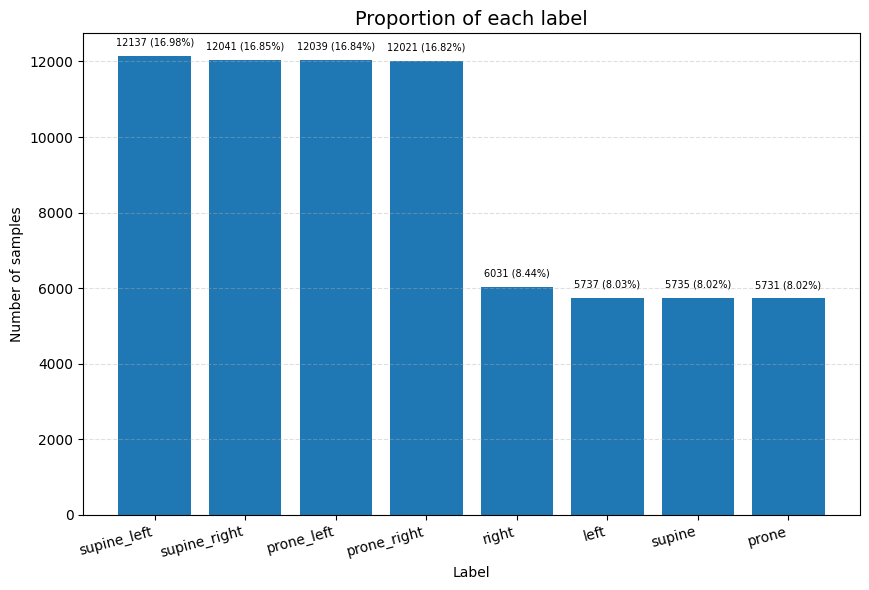

In [ ]:
label_counts = df["label"].value_counts().sort_values(ascending=False)
labels = label_counts.index.tolist()
counts = label_counts.values
percents = (label_counts / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(max(8, 1.1*len(labels)), 6))
bars = ax.bar(labels, counts)

for rect, c, p in zip(bars, counts, percents):
    height = rect.get_height()
    ax.annotate(f"{c} ({p}%)",
                xy=(rect.get_x() + rect.get_width()/2, height),
                xytext=(0, 6),
                textcoords="offset points",
                ha="center", va="bottom", fontsize=7, rotation=0)

ax.set_title("Proportion of each label", fontsize=14)
ax.set_xlabel("Label")
ax.set_ylabel("Number of samples")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
features = ["ax","ay","az","mag"]
features = [f for f in features if f in df.columns]

/tmp/ipython-input-78549961.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_label, labels=labels, showmeans=True)
/tmp/ipython-input-78549961.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_label, labels=labels, showmeans=True)
/tmp/ipython-input-78549961.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_label, labels=labels, showmeans=True)
/tmp/ipython-input-78549961.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplo

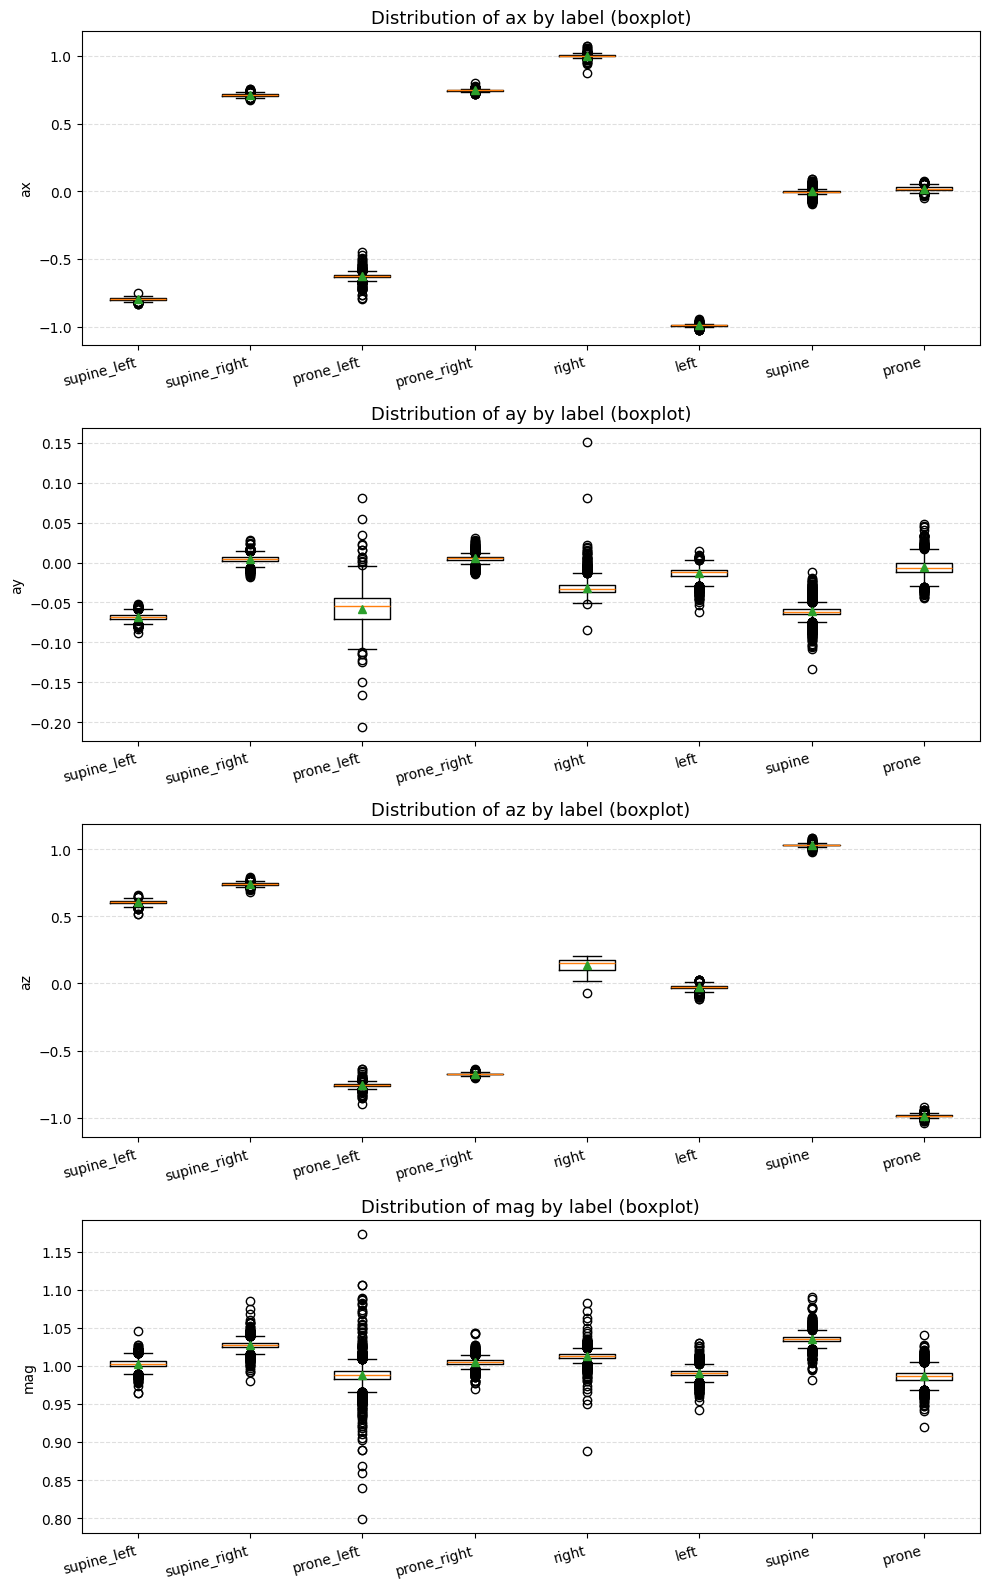

In [ ]:
# Boxplot theo label cho từng đặc trưng
rows = len(features)
fig, axes = plt.subplots(rows, 1, figsize=(max(10, 1.2*len(labels)), 4*rows), squeeze=False)
for i, f in enumerate(features):
    ax = axes[i,0]

    data_by_label = [df[df["label"]==lb][f].values for lb in labels]
    ax.boxplot(data_by_label, labels=labels, showmeans=True)
    ax.set_title(f"Distribution of {f} by label (boxplot)", fontsize=13)
    ax.set_ylabel(f)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
plt.tight_layout()
plt.show()

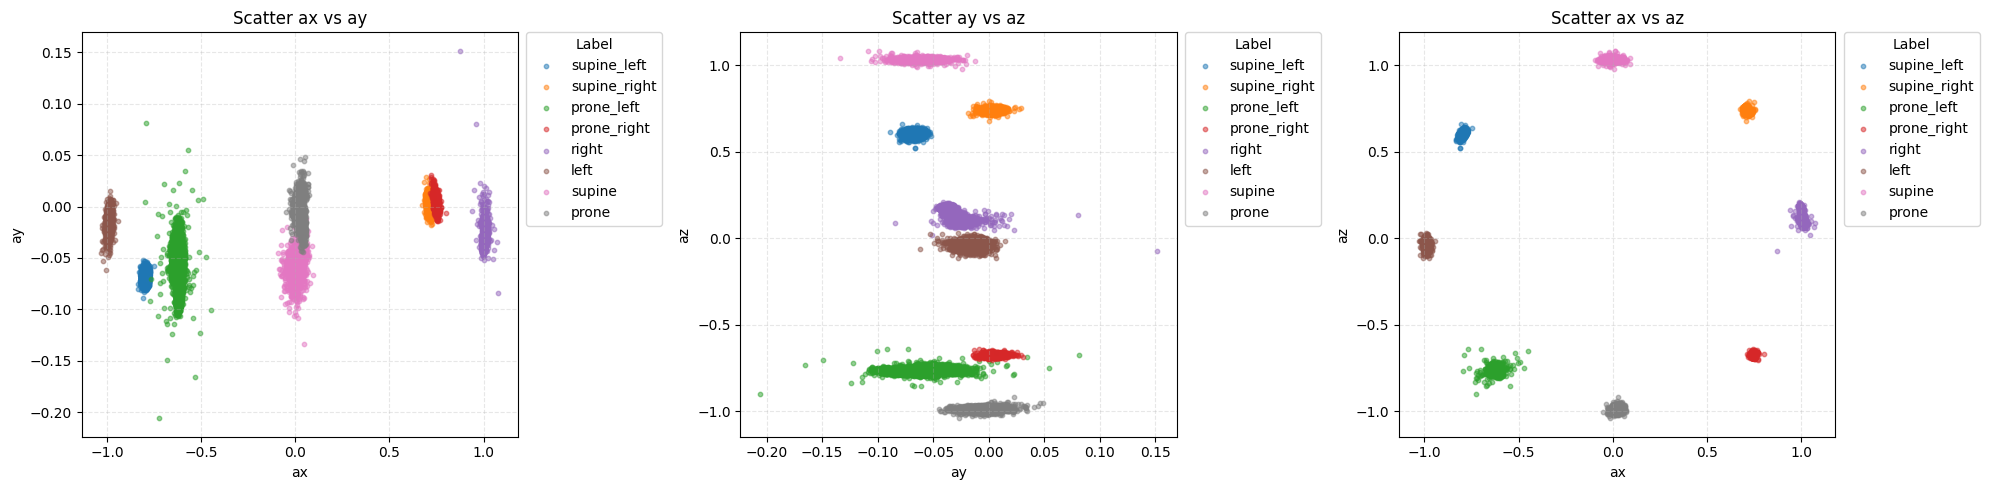

In [ ]:
# Scatter: cặp trục (ax, ay), (ay, az), (ax, az)
pairs = [("ax","ay"), ("ay","az"), ("ax","az")]
pairs = [(x,y) for (x,y) in pairs if x in df.columns and y in df.columns]
if pairs:
    n = len(pairs)
    fig, axes = plt.subplots(1, n, figsize=(6*n + 2, 5), squeeze=False)
    for j, (x, y) in enumerate(pairs):
        ax = axes[0, j]
        for lb in labels:
            tmp = df[df["label"]==lb]
            ax.scatter(tmp[x], tmp[y], s=10, alpha=0.5, label=lb)
        ax.set_xlabel(x)
        ax.set_ylabel(y)
        ax.set_title(f"Scatter {x} vs {y}")
        ax.grid(True, linestyle="--", alpha=0.3)
        bbox = (1.02, 1.0) if n == 1 else (1.02, 1.0)
        ax.legend(title="Label", bbox_to_anchor=bbox, loc="upper left", borderaxespad=0.)
    plt.tight_layout()
    plt.show()

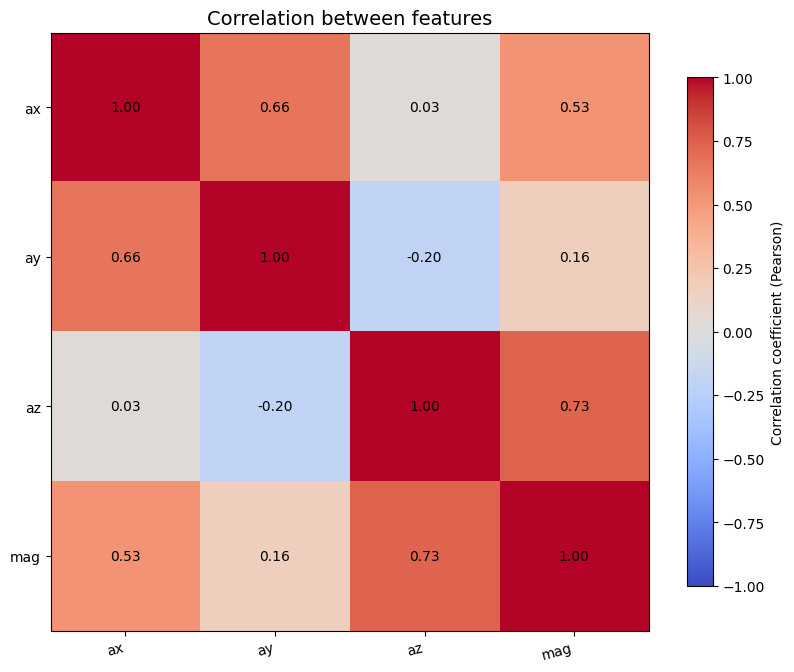

In [ ]:
# Heatmap tương quan (ax, ay, az, mag)
corr = df[features].corr().round(2)

fig, ax = plt.subplots(figsize=(1.6*len(features)+2, 1.2*len(features)+2))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(features)), labels=features, rotation=15, ha="right")
ax.set_yticks(range(len(features)), labels=features)
ax.set_title("Correlation between features", fontsize=14)

for i in range(len(features)):
    for j in range(len(features)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=10, color="black")

cbar = plt.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("Correlation coefficient (Pearson)")
plt.tight_layout()
plt.show()